# CPV301 · EDA bộ GTSRB (bản đóng gói Udacity)
Notebook dành cho buổi giới thiệu dự án. Chỉ kiểm kê và trực quan hóa, không train model.
Dữ liệu gồm train.p, valid.p, test.p; không dùng Dataset/archive (bộ detection khác).
**Colab:** chạy ô mount Drive, kiểm tra DATA_DIR, rồi Run all. Không cần TensorFlow/GPU.
Notebook không sửa mảng đầu vào, không shuffle, normalize hoặc chia lại split để train.
Các phép chia 255 bên dưới chỉ tạo bản sao phục vụ thống kê/hiển thị.
Test chỉ dùng thống kê tổng hợp và kiểm tra trùng ảnh, không chọn hyperparameter.
Nguồn: https://github.com/udacity/CarND-Traffic-Sign-Classifier-Project
Gói tải: https://d17h27t6h515a5.cloudfront.net/topher/2017/February/5898cd6f_traffic-signs-data/traffic-signs-data.zip
Mapping: https://github.com/udacity/CarND-Traffic-Sign-Classifier-Project/blob/master/signnames.csv

In [2]:
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Cấu hình đường dẫn
DATA_DIR phải chứa đủ ba file .p. Nếu thư mục Drive của bạn khác, sửa dòng dưới.
Output mới có timestamp, tránh ghi đè kết quả lần chạy cũ. Không tự tải/gỡ/xóa dữ liệu.
Nếu Colab không có thư viện: chạy `%pip install numpy pandas matplotlib` trong một ô riêng.

In [3]:
import hashlib
import itertools
import json
import pickle
import textwrap
from collections import defaultdict
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

DATA_DIR = Path(os.environ.get('CPV_DATA_DIR',
    '/content/drive/MyDrive/CPV/data/raw_data' if IN_COLAB
    else str(Path.cwd() / '.eda-data/gtsrb-udacity')))
OUTPUT_ROOT = Path(os.environ.get('CPV_OUTPUT_ROOT',
    '/content/drive/MyDrive/CPV/results/EDA' if IN_COLAB
    else str(Path.cwd() / 'EDA/results')))
RUN_DIR = OUTPUT_ROOT / datetime.now().strftime('%Y%m%d_%H%M%S_%f')
RUN_DIR.mkdir(parents=True, exist_ok=False)
FIG_DIR = RUN_DIR / 'figures'
FIG_DIR.mkdir()
SEED = 42
N_CLASSES = 43
SPLIT_ORDER = ['train', 'valid', 'test']
COLORS = {'train': '#0072B2', 'valid': '#E69F00', 'test': '#009E73'}
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 15, 'axes.labelsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 100, 'savefig.dpi': 180})

def show_table(table):
    if 'IPython' in sys.modules:
        from IPython.display import display
        display(table)
    else:
        print(table.to_string(index=False))

figure_files = []
def finish_figure(fig, name):
    """Lưu PNG dùng trên slide; giữ figure inline trong notebook."""
    fig.savefig(FIG_DIR / f'{name}.png', bbox_inches='tight', facecolor='white')
    figure_files.append(f'{name}.png')
    if matplotlib.get_backend().lower() != 'agg':
        plt.show()
    plt.close(fig)

def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

print('Data:', DATA_DIR)
print('Output:', RUN_DIR)
print('Versions:', {'numpy': np.__version__, 'pandas': pd.__version__,
                    'matplotlib': matplotlib.__version__})

Data: /content/drive/MyDrive/CPV/data/raw_data
Output: /content/drive/MyDrive/CPV/results/EDA/20260915_131027_811744
Versions: {'numpy': '2.1.3', 'pandas': '2.2.3', 'matplotlib': '3.10.0'}


## 2. Đọc dữ liệu raw và kiểm tra hợp lệ
Pickle có thể thực thi mã. Chỉ mở dữ liệu từ nguồn đã xác minh.
Loader dưới đây giới hạn các global được phép về lớp/hàm NumPy dùng trong gói này.
Đây là lớp phòng vệ bổ sung, không biến pickle bất kỳ thành an toàn.
Nhãn raw phải là class ID hoặc one-hot nghiêm ngặt. Không argmax mù trên nhãn lỗi.

In [4]:
class NumpyOnlyUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'numpy' and name in {'ndarray', 'dtype'}:
            return getattr(np, name)
        if module in {'numpy.core.multiarray', 'numpy._core.multiarray'} and name in {'_reconstruct', 'scalar'}:
            import importlib
            return getattr(importlib.import_module(module), name)
        raise pickle.UnpicklingError(f'Global không được cho phép: {module}.{name}')

def integer_labels(values):
    y = np.asarray(values)
    if y.ndim == 2 and y.shape[1] == N_CLASSES:
        if not (np.isfinite(y).all() and np.isin(y, [0, 1]).all()
                and np.all(y.sum(axis=1) == 1)):
            raise ValueError('One-hot phải có đúng một số 1 mỗi hàng, các phần tử khác bằng 0.')
        y = y.argmax(axis=1)
    elif y.ndim == 2 and y.shape[1] == 1:
        y = y[:, 0]
    if y.ndim != 1 or not np.issubdtype(y.dtype, np.number):
        raise ValueError('Nhãn phải là vector số nguyên hoặc one-hot 43 lớp.')
    if not np.isfinite(y).all() or not np.equal(y, np.floor(y)).all():
        raise ValueError('Nhãn chứa NaN/Inf hoặc giá trị không nguyên.')
    y = y.astype(np.int64)
    if np.any((y < 0) | (y >= N_CLASSES)):
        raise ValueError('Class ID ngoài khoảng 0..42.')
    return y

splits, audit_rows, file_manifest = {}, [], {}
for split in SPLIT_ORDER:
    path = DATA_DIR / f'{split}.p'
    if not path.is_file():
        raise FileNotFoundError(f'Thiếu {path}. Sửa DATA_DIR, không chọn bộ detection archive.')
    with path.open('rb') as stream:
        raw = NumpyOnlyUnpickler(stream).load()
    if not isinstance(raw, dict) or not {'features', 'labels'} <= raw.keys():
        raise ValueError(f'{split}: cần dictionary features và labels.')
    X, y = np.asarray(raw['features']), integer_labels(raw['labels'])
    if X.ndim != 4 or X.shape[1:] != (32, 32, 3):
        raise ValueError(f'{split}: shape {X.shape}, mong đợi (N,32,32,3).')
    if len(X) == 0 or len(X) != len(y):
        raise ValueError(f'{split}: số ảnh/nhãn không hợp lệ.')
    # Chủ ý fail-fast trên bản raw để không chia 255 lần hai.
    if X.dtype != np.uint8:
        raise ValueError(f'{split}: cần ảnh raw uint8, nhận {X.dtype}. Không dùng ảnh đã normalize.')
    splits[split] = {'X': X, 'y': y}
    counts = np.bincount(y, minlength=N_CLASSES)
    audit_rows.append({'split': split, 'n_images': len(y), 'shape': str(X.shape),
        'dtype': str(X.dtype), 'pixel_min': int(X.min()), 'pixel_max': int(X.max()),
        'n_classes_present': int(np.count_nonzero(counts)),
        'missing_class_ids': ', '.join(map(str, np.flatnonzero(counts == 0))) or 'None'})
    file_manifest[split] = {'name': path.name, 'bytes': path.stat().st_size,
                            'sha256': sha256_file(path)}
    del raw
audit = pd.DataFrame(audit_rows)
total_n = int(audit.n_images.sum())
audit['percent_total'] = audit.n_images / total_n * 100
audit.to_csv(RUN_DIR / 'split_summary.csv', index=False)
show_table(audit)
expected_counts = {'train': 34799, 'valid': 4410, 'test': 12630}
print('Khớp số ảnh checkpoint kế hoạch:',
      all(len(splits[s]['y']) == n for s, n in expected_counts.items()))
print('Mọi thống kê sau đây tính từ file thực tế, không hard-code số lượng checkpoint.')

,split,n_images,shape,dtype,pixel_min,pixel_max,n_classes_present,missing_class_ids,percent_total
0,train,34799,"(34799, 32, 32, 3)",uint8,0,255,43,None,67.128996
1,valid,4410,"(4410, 32, 32, 3)",uint8,0,255,43,None,8.507109
2,test,12630,"(12630, 32, 32, 3)",uint8,0,255,43,None,24.363896


Khớp số ảnh checkpoint kế hoạch: True
Mọi thống kê sau đây tính từ file thực tế, không hard-code số lượng checkpoint.


## 3. Mapping nhãn và số ảnh mỗi lớp
Giữ đúng ID 0..42 trên cả ba split, kể cả lớp có 0 ảnh. Không đổi thứ tự bằng tên lớp.
`all_count` chỉ là thống kê kiểm kê, không ghép dữ liệu để train.

In [5]:
CLASS_NAMES = [
    'Speed limit (20km/h)', 'Speed limit (30km/h)', 'Speed limit (50km/h)',
    'Speed limit (60km/h)', 'Speed limit (70km/h)', 'Speed limit (80km/h)',
    'End of speed limit (80km/h)', 'Speed limit (100km/h)', 'Speed limit (120km/h)',
    'No passing', 'No passing for vehicles over 3.5 metric tons',
    'Right-of-way at the next intersection', 'Priority road', 'Yield', 'Stop',
    'No vehicles', 'Vehicles over 3.5 metric tons prohibited', 'No entry',
    'General caution', 'Dangerous curve to the left', 'Dangerous curve to the right',
    'Double curve', 'Bumpy road', 'Slippery road', 'Road narrows on the right',
    'Road work', 'Traffic signals', 'Pedestrians', 'Children crossing',
    'Bicycles crossing', 'Beware of ice/snow', 'Wild animals crossing',
    'End of all speed and passing limits', 'Turn right ahead', 'Turn left ahead',
    'Ahead only', 'Go straight or right', 'Go straight or left', 'Keep right',
    'Keep left', 'Roundabout mandatory', 'End of no passing',
    'End of no passing by vehicles over 3.5 metric tons']
assert len(CLASS_NAMES) == N_CLASSES
class_counts = pd.DataFrame({'class_id': np.arange(N_CLASSES), 'class_name': CLASS_NAMES})
for split in SPLIT_ORDER:
    class_counts[f'{split}_count'] = np.bincount(splits[split]['y'], minlength=N_CLASSES)
    class_counts[f'{split}_pct'] = class_counts[f'{split}_count'] / len(splits[split]['y']) * 100
class_counts['all_count'] = class_counts[[f'{s}_count' for s in SPLIT_ORDER]].sum(axis=1)
class_counts['all_pct'] = class_counts.all_count / total_n * 100
class_counts.to_csv(RUN_DIR / 'class_distribution.csv', index=False)
show_table(class_counts)

,class_id,class_name,train_count,train_pct,valid_count,valid_pct,test_count,test_pct,all_count,all_pct
0,0,Speed limit (20km/h),180,0.517256,30,0.680272,60,0.475059,270,0.520843
1,1,Speed limit (30km/h),1980,5.689819,240,5.442177,720,5.700713,2940,5.671406
2,2,Speed limit (50km/h),2010,5.776028,240,5.442177,750,5.938242,3000,5.787149
3,3,Speed limit (60km/h),1260,3.620794,150,3.401361,450,3.562945,1860,3.588032
4,4,Speed limit (70km/h),1770,5.086353,210,4.761905,660,5.225653,2640,5.092691
5,5,Speed limit (80km/h),1650,4.741516,210,4.761905,630,4.988124,2490,4.803333
6,6,End of speed limit (80km/h),360,1.034512,60,1.360544,150,1.187648,570,1.099558
7,7,Speed limit (100km/h),1290,3.707003,150,3.401361,450,3.562945,1890,3.645904
8,8,Speed limit (120km/h),1260,3.620794,150,3.401361,450,3.562945,1860,3.588032
9,9,No passing,1320,3.793212,150,3.401361,480,3.800475,1950,3.761647


## 4. Pie chart: tỷ lệ train / validation / test
Mẫu số là tổng số ảnh trong ba file. Pie chart phù hợp vì chỉ có ba phần.
Không dùng pie chart 43 lát để so sánh các lớp.

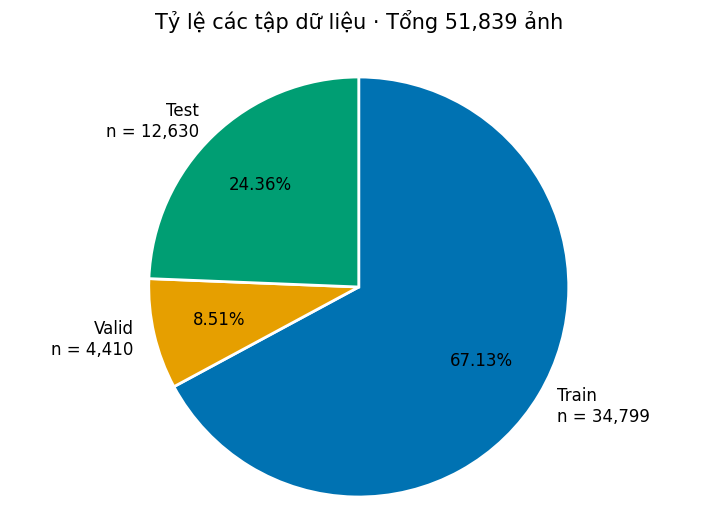

In [6]:
sizes = [len(splits[s]['y']) for s in SPLIT_ORDER]
fig, ax = plt.subplots(figsize=(9, 6))
ax.pie(sizes, labels=[f'{s.title()}\nn = {n:,}' for s, n in zip(SPLIT_ORDER, sizes)],
       colors=[COLORS[s] for s in SPLIT_ORDER], autopct='%1.2f%%',
       startangle=90, counterclock=False, pctdistance=0.68,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2},
       textprops={'fontsize': 12})
ax.set_title(f'Tỷ lệ các tập dữ liệu · Tổng {total_n:,} ảnh', pad=20)
ax.axis('equal')
finish_figure(fig, '01_split_pie')

## 5. Bar chart: phân bố của đủ 43 lớp ở từng split
Trục x là class ID. Trục y là số ảnh (mỗi hàng có thang riêng).
Đường đứt nét là N/43: số ảnh/lớp nếu tập đó cân bằng tuyệt đối.

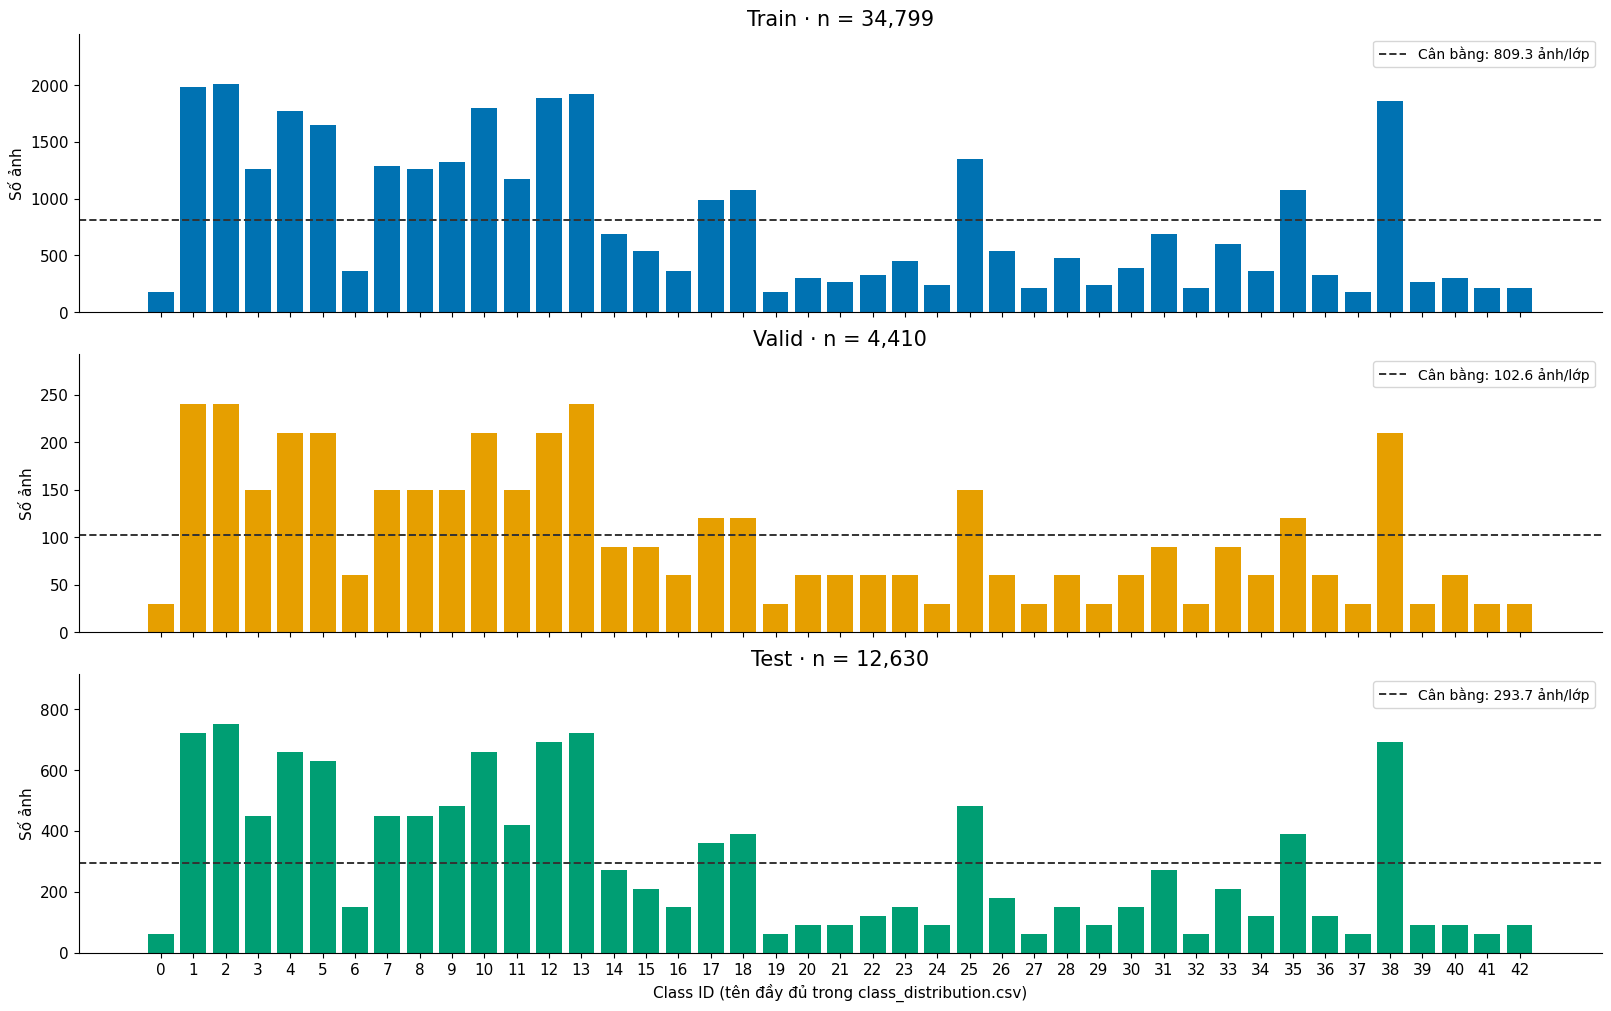

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True, layout='constrained')
for ax, split in zip(axes, SPLIT_ORDER):
    counts = class_counts[f'{split}_count'].to_numpy()
    ax.bar(np.arange(N_CLASSES), counts, color=COLORS[split], width=.8)
    ax.axhline(counts.sum() / N_CLASSES, color='#333333', ls='--', lw=1.4,
               label=f'Cân bằng: {counts.sum()/N_CLASSES:.1f} ảnh/lớp')
    ax.set(title=f'{split.title()} · n = {counts.sum():,}', ylabel='Số ảnh')
    ax.set_ylim(0, max(1, counts.max()*1.22))
    ax.legend(loc='upper right', fontsize=10)
axes[-1].set_xticks(np.arange(N_CLASSES))
axes[-1].set_xlabel('Class ID (tên đầy đủ trong class_distribution.csv)')
finish_figure(fig, '02_class_counts_by_split')

## 6. Định lượng mất cân bằng (class imbalance)
Class ID là biến phân loại. Không tính skewness của dãy số 0..42.
- Imbalance ratio = số ảnh lớp lớn nhất / nhỏ nhất (vô hạn nếu có lớp thiếu).
- Largest-class share = tỷ trọng lớp lớn nhất. Mốc cân bằng là 1/43 = 2.33%.
- TV distance to uniform = 0.5 × tổng |p_i - 1/43|. Bằng 0 khi cân bằng tuyệt đối.
Không có ngưỡng ratio phổ quát để gọi nhẹ/nặng. Báo cáo các số cụ thể.
“Mất cân bằng” không đồng nghĩa “một lớp chiếm đa số hơn 50%”.

,split,min_count,max_count,imbalance_ratio,largest_share_pct,largest_class_ids,smallest_class_ids,tv_to_uniform,exactly_uniform
0,train,180,2010,11.166667,5.776028,2,"0,19,37",0.342603,False
1,valid,30,240,8.000000,5.442177,"1,2,13","0,19,24,27,29,32,37,39,41,42",0.291726,False
2,test,60,750,12.500000,5.938242,2,"0,19,27,32,37,41",0.348119,False
3,all,270,3000,11.111111,5.787149,2,"0,19,37",0.339619,False


Train: ratio max/min = 11.17; lớp lớn nhất chiếm 5.78%.
Train không cân bằng. Cần đánh giá macro-F1 và recall từng lớp bên cạnh accuracy.
Không có một lớp nào chiếm đa số hơn 50%.


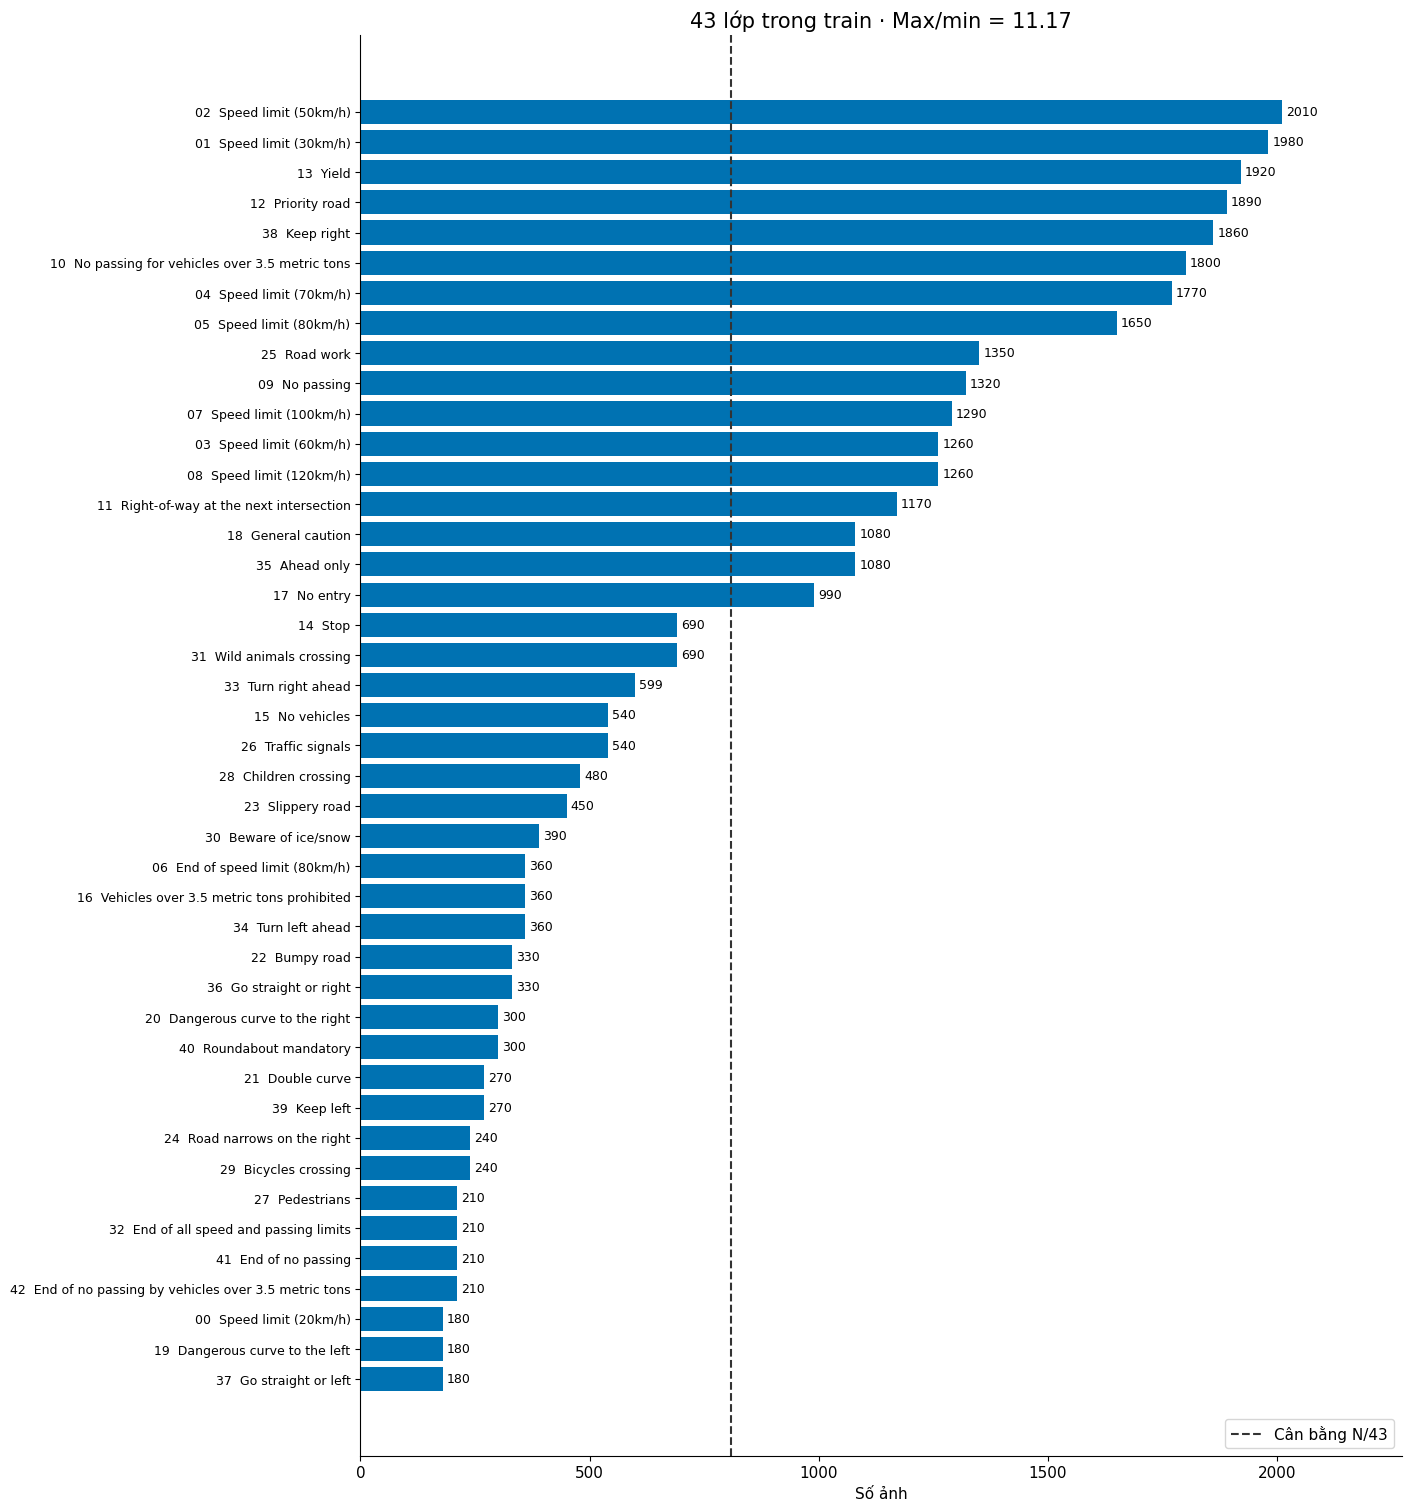

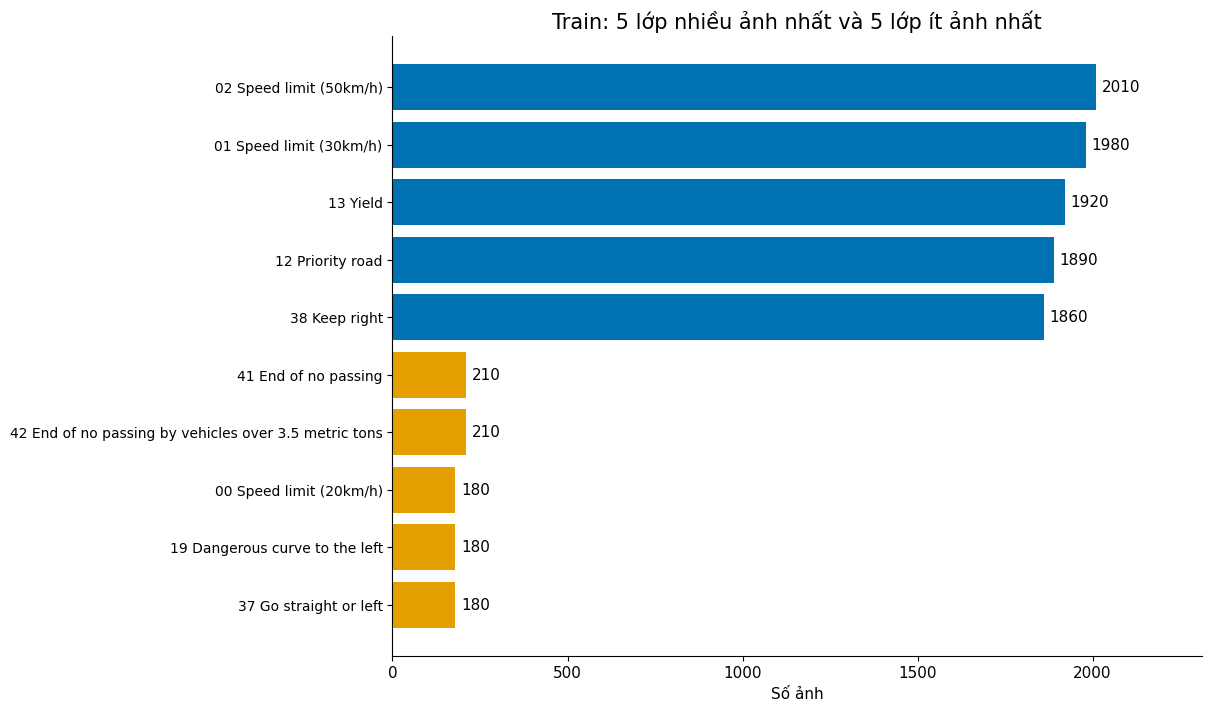

In [8]:
def imbalance_metrics(counts):
    counts = np.asarray(counts, dtype=np.int64)
    if counts.shape != (N_CLASSES,) or (counts < 0).any() or counts.sum() == 0:
        raise ValueError('Cần vector 43 counts không âm và tổng > 0.')
    p = counts / counts.sum()
    return {'min_count': int(counts.min()), 'max_count': int(counts.max()),
        'imbalance_ratio': float(counts.max()/counts.min()) if counts.min() else float('inf'),
        'largest_share_pct': float(p.max()*100),
        'largest_class_ids': ','.join(map(str, np.flatnonzero(counts == counts.max()))),
        'smallest_class_ids': ','.join(map(str, np.flatnonzero(counts == counts.min()))),
        'tv_to_uniform': float(np.abs(p - 1/N_CLASSES).sum()/2),
        'exactly_uniform': bool(np.all(counts == counts[0]))}

imbalance = pd.DataFrame([{'split': s, **imbalance_metrics(class_counts[f'{s}_count'])}
                         for s in SPLIT_ORDER + ['all']])
imbalance.to_csv(RUN_DIR / 'imbalance_summary.csv', index=False)
show_table(imbalance)
train_counts = class_counts.train_count.to_numpy()
train_info = imbalance_metrics(train_counts)
print(f"Train: ratio max/min = {train_info['imbalance_ratio']:.2f}; "
      f"lớp lớn nhất chiếm {train_info['largest_share_pct']:.2f}%.")
print('Train cân bằng tuyệt đối.' if train_info['exactly_uniform']
      else 'Train không cân bằng. Cần đánh giá macro-F1 và recall từng lớp bên cạnh accuracy.')
print('Có một lớp chiếm hơn 50%.' if train_info['largest_share_pct'] > 50
      else 'Không có một lớp nào chiếm đa số hơn 50%.')

# Toàn bộ 43 lớp, xếp hạng theo số ảnh train. Phù hợp đọc báo cáo/zoom.
rank = np.argsort(-train_counts, kind='stable')
fig, ax = plt.subplots(figsize=(14, 15), layout='constrained')
bars = ax.barh(np.arange(N_CLASSES), train_counts[rank], color=COLORS['train'])
ax.set_yticks(np.arange(N_CLASSES), [f'{i:02d}  {CLASS_NAMES[i]}' for i in rank], fontsize=9)
ax.invert_yaxis()
ax.bar_label(bars, padding=3, fontsize=9)
ax.axvline(train_counts.mean(), color='#333333', ls='--', label='Cân bằng N/43')
ax.set_xlim(0, train_counts.max()*1.13)
ax.set(title=f'43 lớp trong train · Max/min = {train_info["imbalance_ratio"]:.2f}', xlabel='Số ảnh')
ax.legend(loc='lower right')
finish_figure(fig, '03_train_all_classes_ranked')

# Bản rút gọn để dùng trên slide. Khi bằng số lượng, giữ thứ tự ID trong rank;
# có thể có các lớp cùng số ảnh ở ranh giới top/bottom nhưng không được chọn vào hình này.
selected = np.r_[rank[:5], rank[-5:]]
fig, ax = plt.subplots(figsize=(12, 7), layout='constrained')
bars = ax.barh(np.arange(10), train_counts[selected],
               color=[COLORS['train']]*5 + [COLORS['valid']]*5)
ax.set_yticks(np.arange(10), [f'{i:02d} {CLASS_NAMES[i]}' for i in selected], fontsize=10)
ax.invert_yaxis()
ax.bar_label(bars, padding=4)
ax.set_xlim(0, train_counts.max()*1.15)
ax.set(title='Train: 5 lớp nhiều ảnh nhất và 5 lớp ít ảnh nhất', xlabel='Số ảnh')
finish_figure(fig, '04_train_top_bottom_5')

## 7. Heatmap: so sánh tỷ trọng nhãn giữa các split
Mỗi hàng chia cho số ảnh của chính split đó, nên có thể so sánh dù N khác nhau.
TV giữa hai split chỉ phản ánh phân bố nhãn, không chứng minh ảnh cùng phân phối.
Không dùng kết quả test để chọn augmentation/class weights. Nếu cần, tính weights từ train.

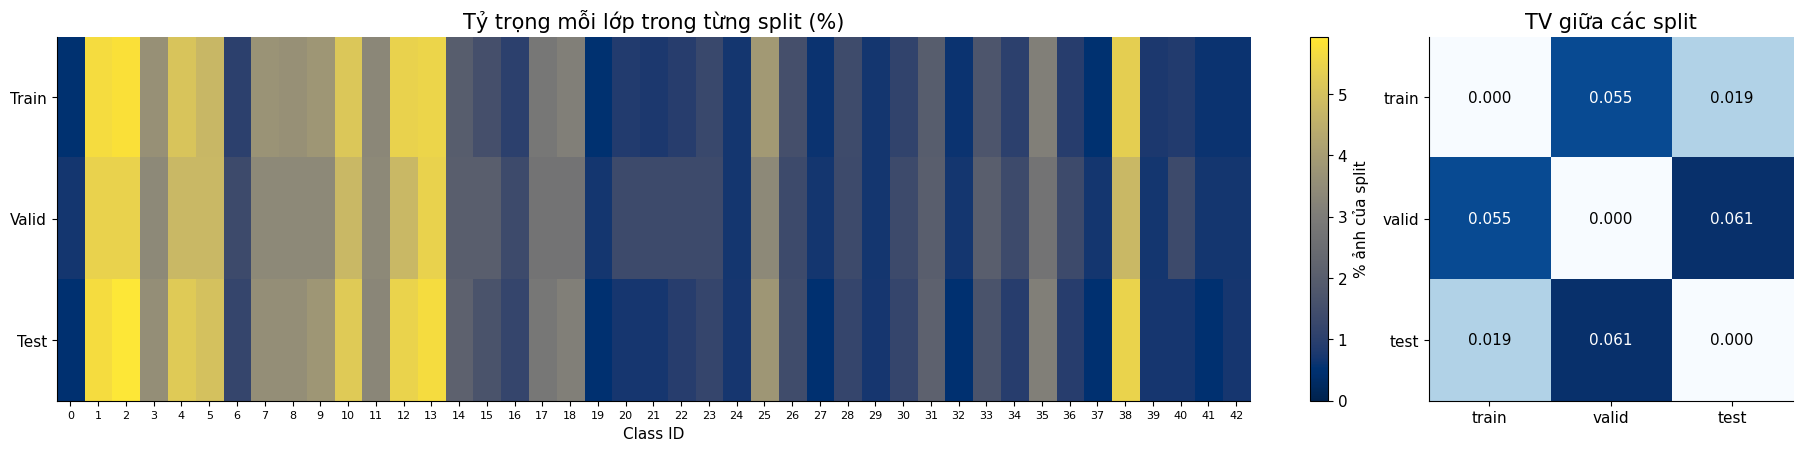

In [9]:
pct = np.vstack([class_counts[f'{s}_pct'].to_numpy() for s in SPLIT_ORDER])
fig, axes = plt.subplots(1, 2, figsize=(18, 4.4), layout='constrained',
                         gridspec_kw={'width_ratios': [5, 1.6]})
im = axes[0].imshow(pct, aspect='auto', cmap='cividis', vmin=0, vmax=pct.max())
axes[0].set_xticks(np.arange(N_CLASSES))
axes[0].tick_params(axis='x', labelsize=8)
axes[0].set_yticks(np.arange(3), ['Train', 'Valid', 'Test'])
axes[0].set(title='Tỷ trọng mỗi lớp trong từng split (%)', xlabel='Class ID')
fig.colorbar(im, ax=axes[0], label='% ảnh của split')
tv = np.array([[np.abs(a-b).sum()/200 for b in pct] for a in pct])
im2 = axes[1].imshow(tv, cmap='Blues', vmin=0, vmax=max(tv.max(), .01))
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f'{tv[i,j]:.3f}', ha='center', va='center',
                     color='white' if tv[i,j] > max(tv.max(), .01)*.65 else 'black')
axes[1].set_xticks(range(3), SPLIT_ORDER)
axes[1].set_yticks(range(3), SPLIT_ORDER)
axes[1].set_title('TV giữa các split')
finish_figure(fig, '05_class_proportion_heatmap')
pd.DataFrame(tv, index=SPLIT_ORDER, columns=SPLIT_ORDER).to_csv(RUN_DIR/'label_tv_distance.csv')

## 8. Một ảnh train cho mỗi lớp
Chọn ngẫu nhiên có seed. Đây là gallery minh họa, không đại diện cho toàn bộ biến thiên.
Phóng lớn bằng nearest để không tạo ấn tượng ảnh gốc có độ phân giải cao.

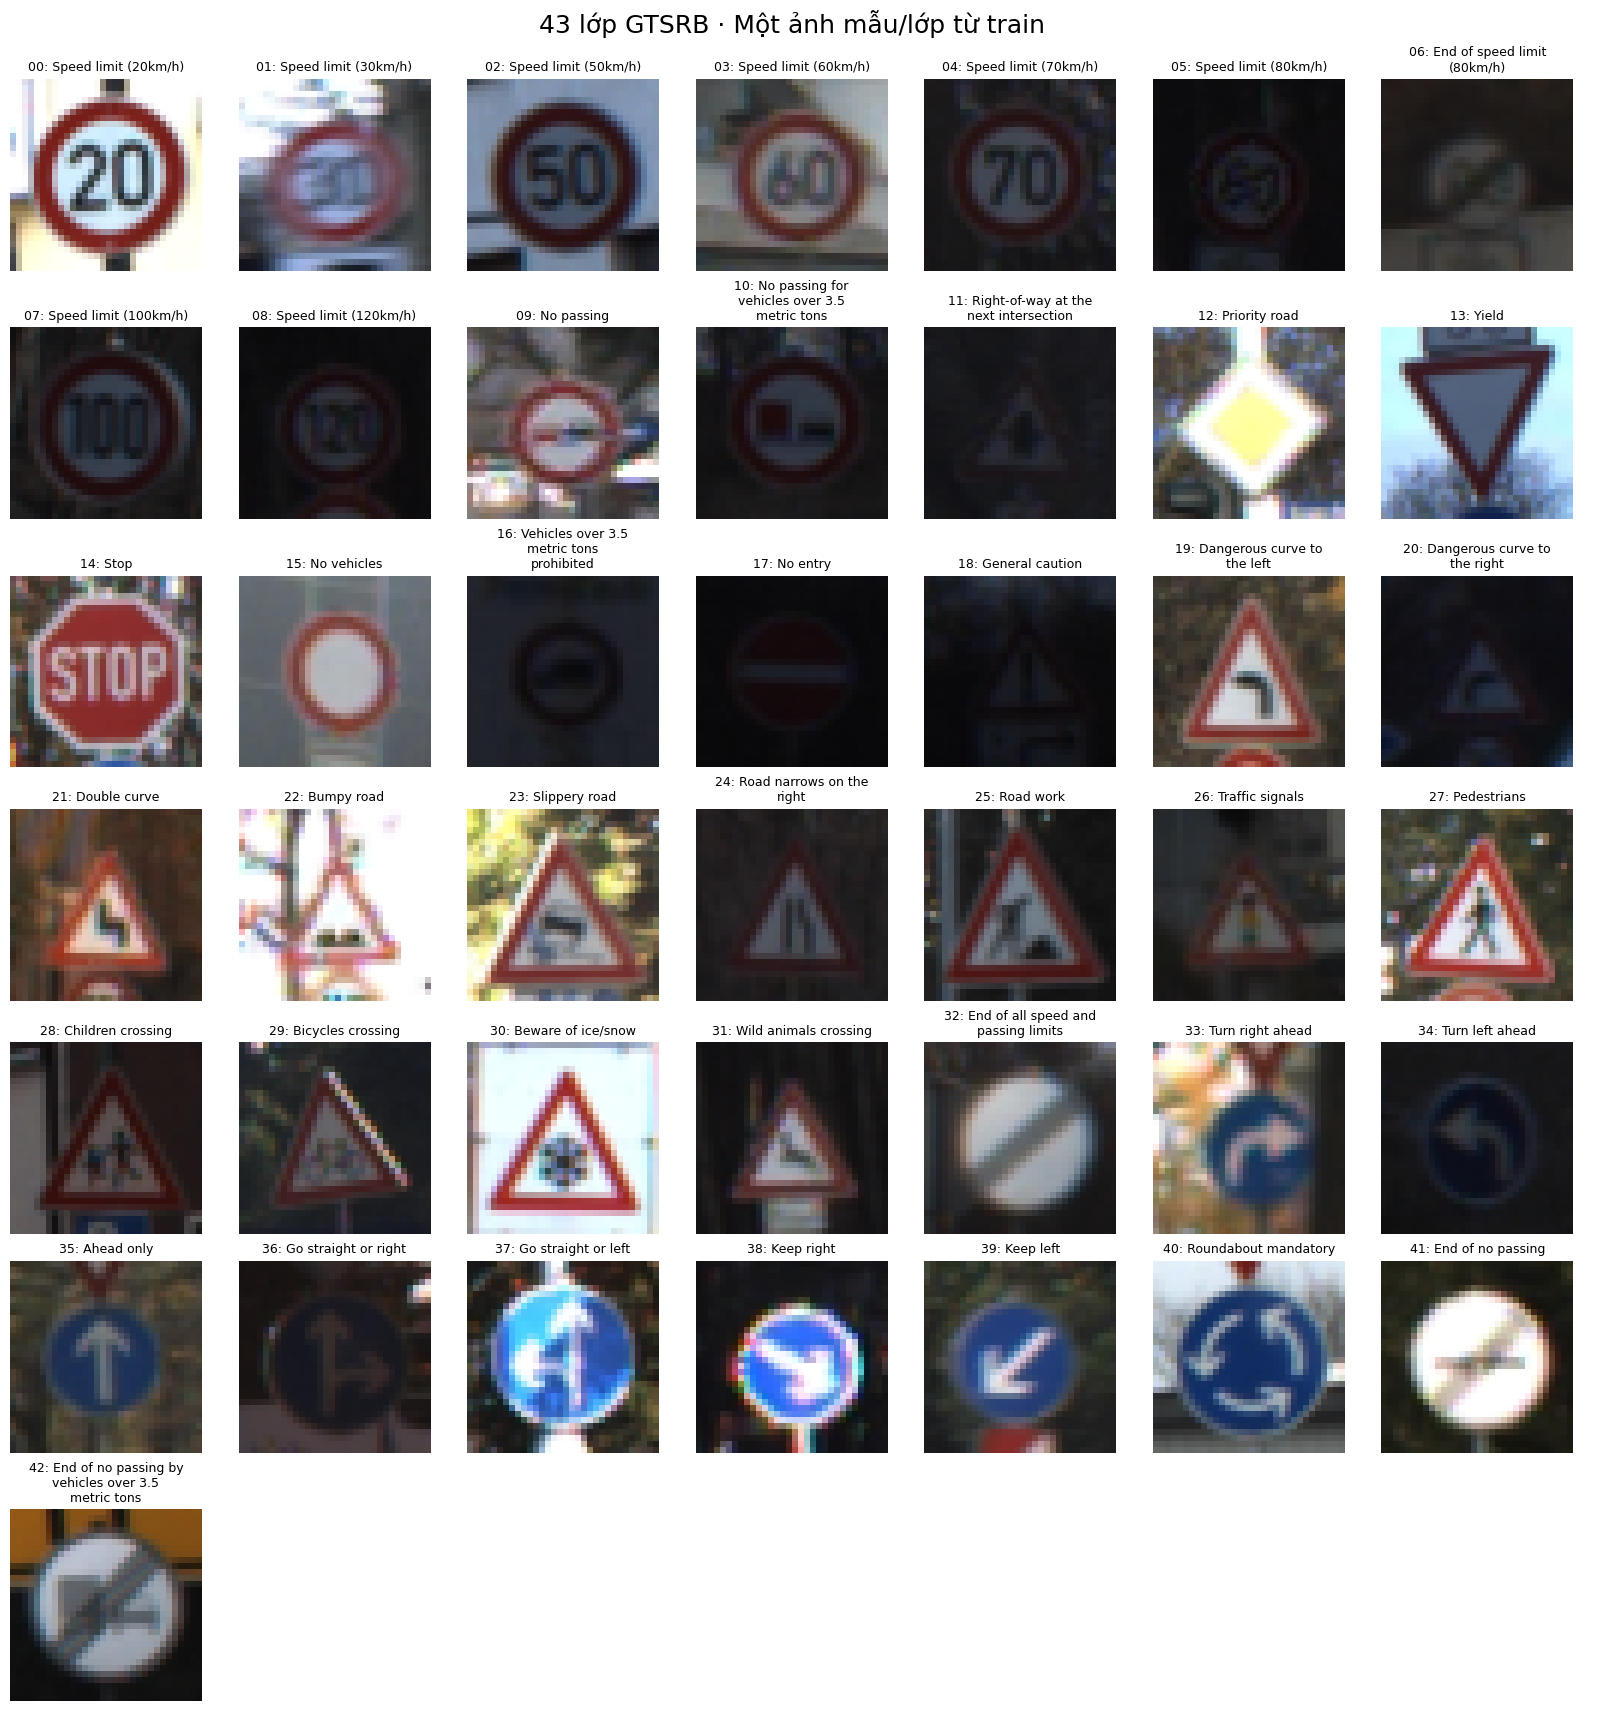

In [10]:
X_train, y_train = splits['train']['X'], splits['train']['y']
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(7, 7, figsize=(16, 17), layout='constrained')
gallery_indices = {}
for class_id, ax in enumerate(axes.flat):
    ax.axis('off')
    if class_id >= N_CLASSES:
        continue
    indices = np.flatnonzero(y_train == class_id)
    if len(indices):
        idx = int(rng.choice(indices))
        gallery_indices[class_id] = idx
        ax.imshow(X_train[idx], interpolation='nearest')
    else:
        ax.text(.5, .5, 'Không có ảnh', ha='center')
    ax.set_title(f'{class_id:02d}: ' + textwrap.fill(CLASS_NAMES[class_id], 21), fontsize=9)
fig.suptitle('43 lớp GTSRB · Một ảnh mẫu/lớp từ train', fontsize=18)
finish_figure(fig, '06_gallery_43_classes')

## 9. Độ sáng và độ tương phản của ảnh train
Tính toàn bộ train theo batch để tránh tạo mảng float32 quá lớn.
Y' = 0.299R + 0.587G + 0.114B trên RGB [0,1] là proxy độ sáng, không phải phép đo vật lý.
Brightness = mean Y'; contrast = std Y'. Không diễn giải contrast thấp là ảnh sai/hỏng.

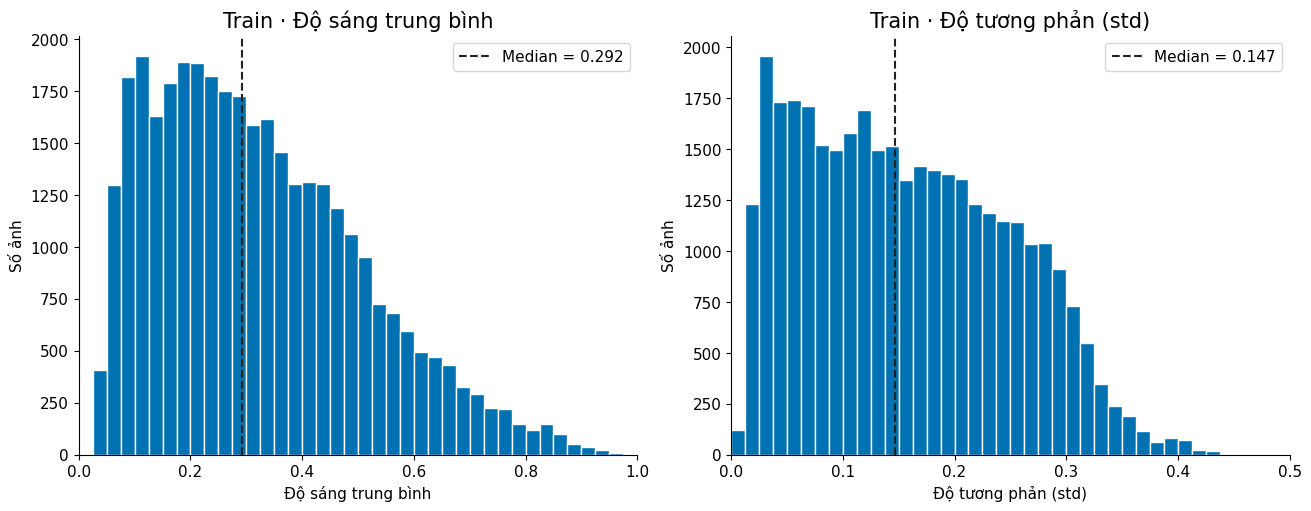

In [11]:
brightness_parts, contrast_parts = [], []
for start in range(0, len(X_train), 512):
    batch = X_train[start:start+512].astype(np.float32)/255.0
    gray = batch @ np.array([.299, .587, .114], dtype=np.float32)
    brightness_parts.append(gray.mean(axis=(1, 2)))
    contrast_parts.append(gray.std(axis=(1, 2)))
brightness = np.concatenate(brightness_parts)
contrast = np.concatenate(contrast_parts)
quality = pd.DataFrame({'train_index': np.arange(len(y_train)), 'class_id': y_train,
                        'brightness': brightness, 'contrast': contrast})
quality.to_csv(RUN_DIR/'train_image_quality.csv', index=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout='constrained')
for ax, values, title, upper in zip(axes, [brightness, contrast],
    ['Độ sáng trung bình', 'Độ tương phản (std)'], [1, .5]):
    ax.hist(values, bins=np.linspace(0, upper, 41), color=COLORS['train'], edgecolor='white')
    median = np.median(values)
    ax.axvline(median, color='#222222', ls='--', label=f'Median = {median:.3f}')
    ax.set(title=f'Train · {title}', xlabel=title, ylabel='Số ảnh', xlim=(0, upper))
    ax.legend()
finish_figure(fig, '07_brightness_contrast')

## 10. Ví dụ ảnh rất tối, rất sáng và tương phản thấp
Sáu ảnh ở mỗi hàng là các cực trị thực đo trên train, không phải mẫu ngẫu nhiên.
Kiểm tra mắt trước khi quyết định augmentation. Notebook không tự loại bỏ các ảnh này.

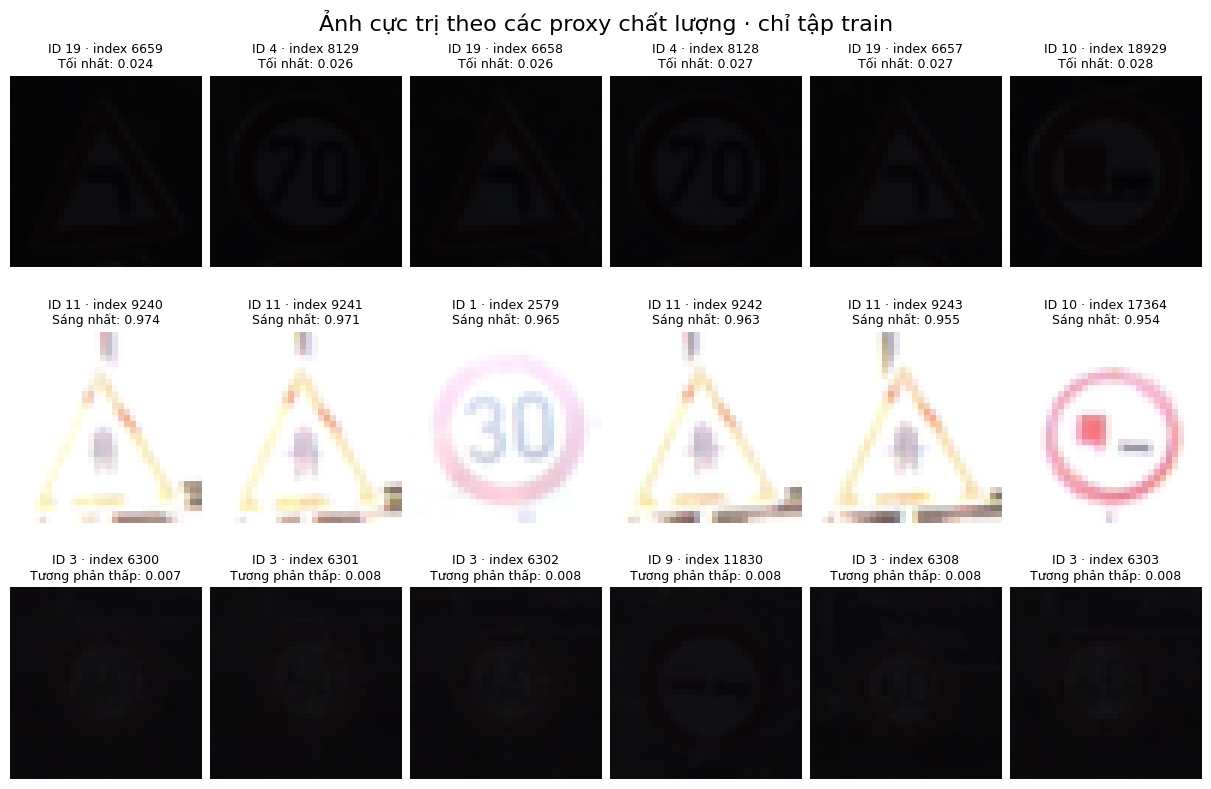

In [12]:
groups = [('Tối nhất', np.argsort(brightness)[:6], brightness),
          ('Sáng nhất', np.argsort(-brightness)[:6], brightness),
          ('Tương phản thấp', np.argsort(contrast)[:6], contrast)]
fig, axes = plt.subplots(3, 6, figsize=(12, 8), layout='constrained')
for row, (label, indices, values) in enumerate(groups):
    for col, idx in enumerate(indices):
        ax = axes[row, col]
        ax.imshow(X_train[idx], interpolation='nearest')
        ax.set_title(f'ID {y_train[idx]} · index {idx}\n{label}: {values[idx]:.3f}', fontsize=9)
        ax.axis('off')
fig.suptitle('Ảnh cực trị theo các proxy chất lượng · chỉ tập train', fontsize=16)
finish_figure(fig, '08_quality_examples')

## 11. Phân bố cường độ RGB
Lấy mẫu tối đa 2,000 ảnh train có seed; các histogram có chung bin 0..255.
Mẫu số là số pixel trong mẫu. Không coi từng pixel là một quan sát độc lập để kiểm định.
Hình giúp phát hiện ảnh quá tối/bão hòa và xác nhận vẫn giữ thông tin màu.

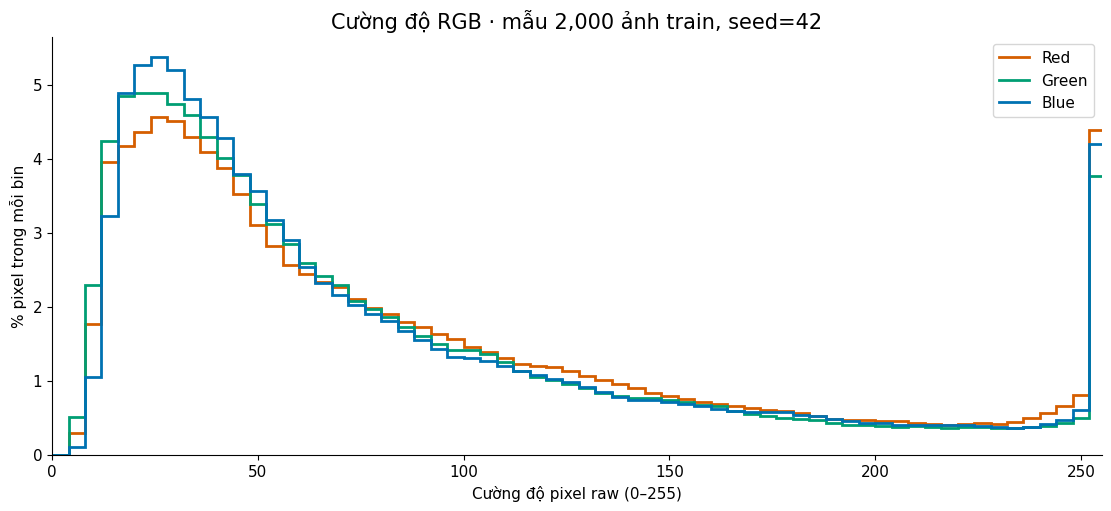

In [13]:
sample_rng = np.random.default_rng(SEED)
rgb_indices = sample_rng.choice(len(X_train), size=min(2000, len(X_train)), replace=False)
rgb_sample = X_train[rgb_indices]
fig, ax = plt.subplots(figsize=(11, 5), layout='constrained')
edges = np.arange(0, 257, 4)
for channel, color, label in [(0, '#D55E00', 'Red'), (1, '#009E73', 'Green'), (2, '#0072B2', 'Blue')]:
    values = rgb_sample[..., channel].ravel()
    hist, _ = np.histogram(values, bins=edges)
    ax.stairs(hist/hist.sum()*100, edges, label=label, color=color, linewidth=2)
ax.set(title=f'Cường độ RGB · mẫu {len(rgb_indices):,} ảnh train, seed={SEED}',
       xlabel='Cường độ pixel raw (0–255)', ylabel='% pixel trong mỗi bin', xlim=(0, 255))
ax.legend()
finish_figure(fig, '09_rgb_histogram')

## 12. Kiểm tra ảnh trùng pixel giữa các split
Hash SHA-256 của từng tensor uint8. Số lượng là số **nội dung ảnh duy nhất** trùng nhau,
không phải số cặp ảnh. Chỉ phát hiện trùng pixel tuyệt đối; khác góc nhìn/crop có thể cùng biển.
Không có trùng hash không chứng minh không rò rỉ theo track. Không tự xóa/chia lại dữ liệu.

,split,unique_images,extra_exact_duplicates,conflicting_label_hashes
0,train,34799,0,0
1,valid,4410,0,0
2,test,12630,0,0


,split_a,split_b,shared_unique_pixel_hashes,conflicting_label_hashes
0,train,valid,0,0
1,train,test,0,0
2,valid,test,0,0


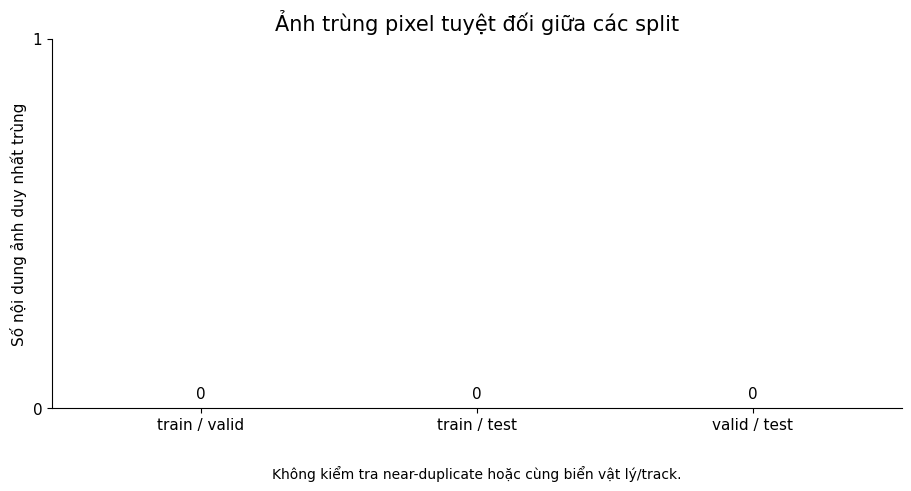

In [14]:
hash_groups = {}
duplicate_rows = []
for split in SPLIT_ORDER:
    grouped = defaultdict(list)
    for index, img in enumerate(splits[split]['X']):
        grouped[hashlib.sha256(img.tobytes()).hexdigest()].append(index)
    hash_groups[split] = grouped
    conflicting = sum(len({int(splits[split]['y'][i]) for i in indices}) > 1
                      for indices in grouped.values())
    duplicate_rows.append({'split': split, 'unique_images': len(grouped),
        'extra_exact_duplicates': len(splits[split]['X'])-len(grouped),
        'conflicting_label_hashes': int(conflicting)})
duplicates = pd.DataFrame(duplicate_rows)
duplicates.to_csv(RUN_DIR/'within_split_duplicates.csv', index=False)
show_table(duplicates)
overlap_rows = []
for a, b in itertools.combinations(SPLIT_ORDER, 2):
    shared = set(hash_groups[a]) & set(hash_groups[b])
    conflict = sum(len({int(splits[s]['y'][i]) for s in [a,b]
                       for i in hash_groups[s][h]}) > 1 for h in shared)
    overlap_rows.append({'split_a': a, 'split_b': b,
        'shared_unique_pixel_hashes': len(shared), 'conflicting_label_hashes': int(conflict)})
overlap = pd.DataFrame(overlap_rows)
overlap.to_csv(RUN_DIR/'cross_split_duplicates.csv', index=False)
show_table(overlap)
fig, ax = plt.subplots(figsize=(9, 4.8), layout='constrained')
bars = ax.bar([f'{r.split_a} / {r.split_b}' for r in overlap.itertuples()],
              overlap.shared_unique_pixel_hashes, color='#666666')
ax.bar_label(bars, padding=5)
ax.set_ylim(0, max(1, overlap.shared_unique_pixel_hashes.max()*1.3))
from matplotlib.ticker import MaxNLocator
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set(title='Ảnh trùng pixel tuyệt đối giữa các split', ylabel='Số nội dung ảnh duy nhất trùng')
ax.text(.5, -.19, 'Không kiểm tra near-duplicate hoặc cùng biển vật lý/track.',
         ha='center', transform=ax.transAxes, fontsize=10)
finish_figure(fig, '10_cross_split_duplicates')

## 13. Kết luận tự sinh và gợi ý trình bày
Chỉ dùng số đo từ lần chạy này. Báo cáo EDA khác với kết quả chất lượng model.
Bước tiếp theo: giữ nguyên split, huấn luyện baseline, dùng macro-F1/recall theo lớp.
Class weights (nếu thử) phải tính trên train và so sánh có kiểm soát bằng validation.
Chưa có dự đoán nên không tạo confusion matrix, ROC hoặc learning curves giả.

In [15]:
summary_lines = [f'Tổng ảnh: {total_n:,}.']
for row in audit.itertuples():
    summary_lines.append(f'{row.split}: {row.n_images:,} ảnh ({row.percent_total:.2f}%), '
                         f'{row.n_classes_present}/43 lớp.')
summary_lines += [
    f'Train max/min = {train_info["max_count"]}/{train_info["min_count"]} = {train_info["imbalance_ratio"]:.2f}.',
    f'Lớp nhiều nhất: ID {train_info["largest_class_ids"]}; tỷ trọng {train_info["largest_share_pct"]:.2f}%.',
    f'Lớp ít nhất: ID {train_info["smallest_class_ids"]}.',
    f'Độ sáng train: min={brightness.min():.3f}, median={np.median(brightness):.3f}, max={brightness.max():.3f}.',
    f'Tổng hash trùng giữa các cặp split: {overlap.shared_unique_pixel_hashes.sum()} (không kiểm tra track).',
    'Chưa huấn luyện/đánh giá mô hình trong notebook này. Không có số accuracy hoặc macro-F1 đã đo.',
]
print('\n'.join(summary_lines))
(RUN_DIR/'findings.txt').write_text('\n'.join(summary_lines)+'\n', encoding='utf-8')
manifest = {'run_utc': datetime.now(timezone.utc).isoformat(), 'seed': SEED,
    'source_url': 'https://d17h27t6h515a5.cloudfront.net/topher/2017/February/5898cd6f_traffic-signs-data/traffic-signs-data.zip',
    'class_mapping_source': 'https://github.com/udacity/CarND-Traffic-Sign-Classifier-Project/blob/master/signnames.csv',
    'data_path': str(DATA_DIR), 'files': file_manifest, 'figures': figure_files,
    'versions': {'python': sys.version, 'numpy': np.__version__, 'pandas': pd.__version__, 'matplotlib': matplotlib.__version__},
    'gallery_train_indices': gallery_indices, 'rgb_sample_size': len(rgb_indices),
    'scope': 'Raw split audit; class counts for all splits; image-quality EDA on train only; no model training.'}
(RUN_DIR/'manifest.json').write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding='utf-8')
assert len(figure_files) == 10
assert class_counts.all_count.sum() == total_n
assert np.allclose(audit.percent_total.sum(), 100)
print('Đã lưu 10 PNG và các bảng CSV vào:', RUN_DIR)

Tổng ảnh: 51,839.
train: 34,799 ảnh (67.13%), 43/43 lớp.
valid: 4,410 ảnh (8.51%), 43/43 lớp.
test: 12,630 ảnh (24.36%), 43/43 lớp.
Train max/min = 2010/180 = 11.17.
Lớp nhiều nhất: ID 2; tỷ trọng 5.78%.
Lớp ít nhất: ID 0,19,37.
Độ sáng train: min=0.024, median=0.292, max=0.974.
Tổng hash trùng giữa các cặp split: 0 (không kiểm tra track).
Chưa huấn luyện/đánh giá mô hình trong notebook này. Không có số accuracy hoặc macro-F1 đã đo.
Đã lưu 10 PNG và các bảng CSV vào: /content/drive/MyDrive/CPV/results/EDA/20260915_131027_811744
